## Load Dataset

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Exploratory Data Analysis

In [39]:
df.shape

(32581, 12)

In [40]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [42]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [43]:
print('MINIMUM :\n',df.min())
print('\n')
print('MAXIMUM :\n',df.max())

MINIMUM :
 person_age                                   20
person_income                              4000
person_home_ownership                  MORTGAGE
person_emp_length                           0.0
loan_intent                   DEBTCONSOLIDATION
loan_grade                                    A
loan_amnt                                   500
loan_int_rate                              5.42
loan_status                                   0
loan_percent_income                         0.0
cb_person_default_on_file                     N
cb_person_cred_hist_length                    2
dtype: object


MAXIMUM :
 person_age                        144
person_income                 6000000
person_home_ownership            RENT
person_emp_length               123.0
loan_intent                   VENTURE
loan_grade                          G
loan_amnt                       35000
loan_int_rate                   23.22
loan_status                         1
loan_percent_income              0.83
cb_per

In [44]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [45]:
((df[['person_emp_length','loan_int_rate']].isna().sum()/len(df)) * 100).round(2)

person_emp_length    2.75
loan_int_rate        9.56
dtype: float64

## Handling duplicates

In [46]:
df.duplicated().sum()

np.int64(165)

In [47]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [48]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (32416, 12)


## Handling missing values and extreame values

In [49]:
df['person_age'] = df['person_age'].clip(upper=80)
df['person_emp_length'] = df['person_emp_length'].clip(upper=60)

In [50]:
df['person_income'] = df['person_income'].clip(upper=df['person_income'].quantile(0.99))

In [51]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [52]:
df.isnull().sum().sum()

np.int64(0)

In [53]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.737876,64354.202770,4.764993,9593.845632,11.014662,0.218688,0.170250,5.811297
std,6.238629,37800.895594,4.007142,6322.730241,3.083050,0.413363,0.106812,4.059030
min,20.000000,4000.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,38542.000000,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,79218.000000,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,80.000000,225000.000000,60.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Univariate analysis

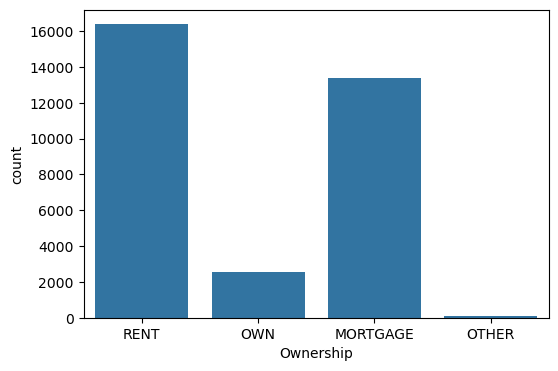

In [54]:
plt.figure(figsize = (6,4))
sns.countplot(x = df['person_home_ownership'])

plt.xlabel('Ownership')
plt.ylabel('count')
plt.show()

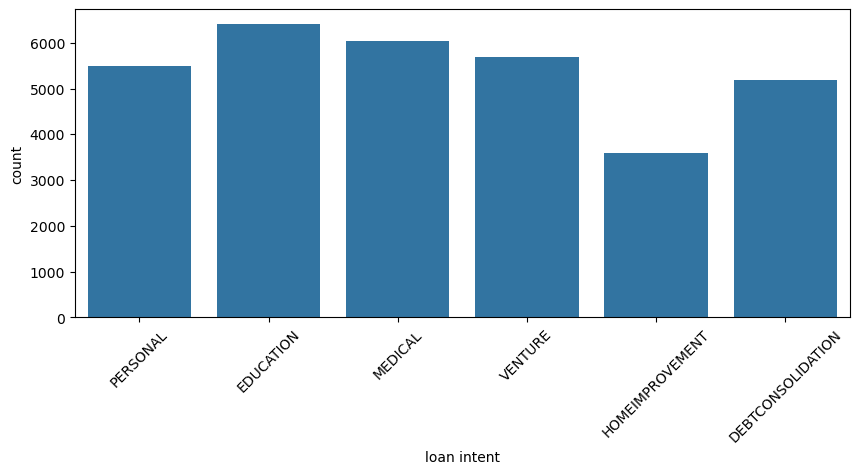

In [55]:
plt.figure(figsize = (10,4))
sns.countplot(x = df['loan_intent'])

plt.xticks(rotation = 45)
plt.xlabel('loan intent')
plt.ylabel('count')
plt.show()

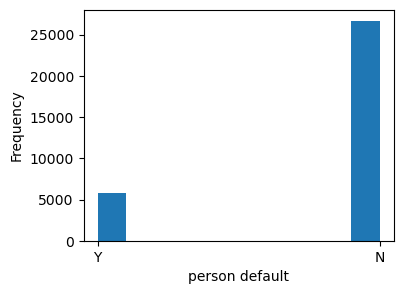

In [56]:
plt.figure(figsize = (4,3))

plt.hist(df['cb_person_default_on_file'])

plt.xlabel('person default')
plt.ylabel('Frequency')
plt.show()

In [57]:
df['loan_status'].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

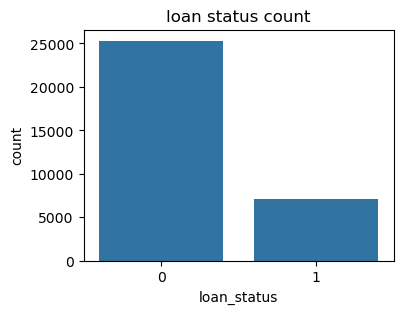

In [58]:
plt.figure(figsize = (4,3))

sns.countplot(x = 'loan_status', data = df)

plt.title('loan status count')
plt.show()

##  bivariate analysis

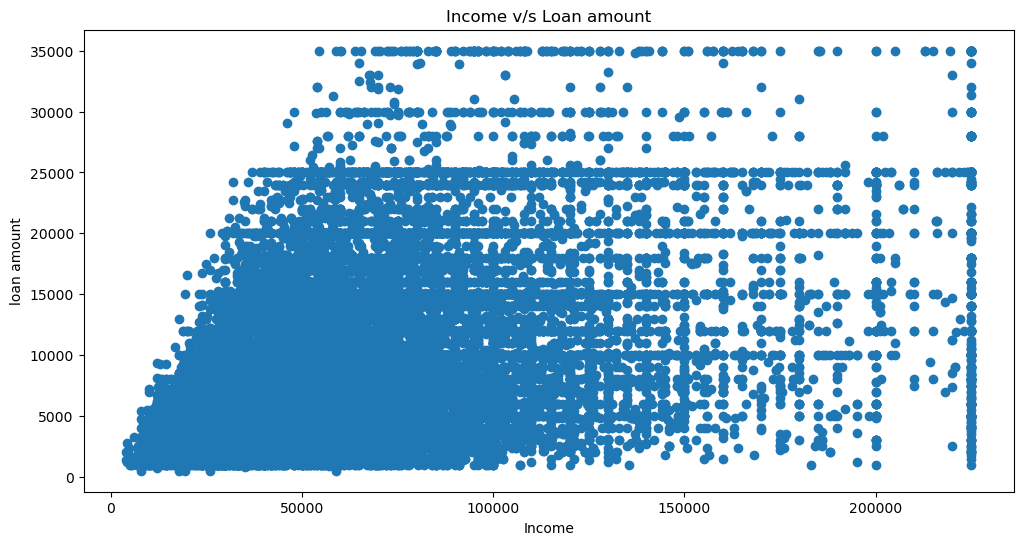

In [59]:
plt.figure(figsize = (12,6))

plt.scatter(x = df['person_income'], y = df['loan_amnt'])

plt.title('Income v/s Loan amount')
plt.xlabel('Income')
plt.ylabel('loan amount')
plt.show()

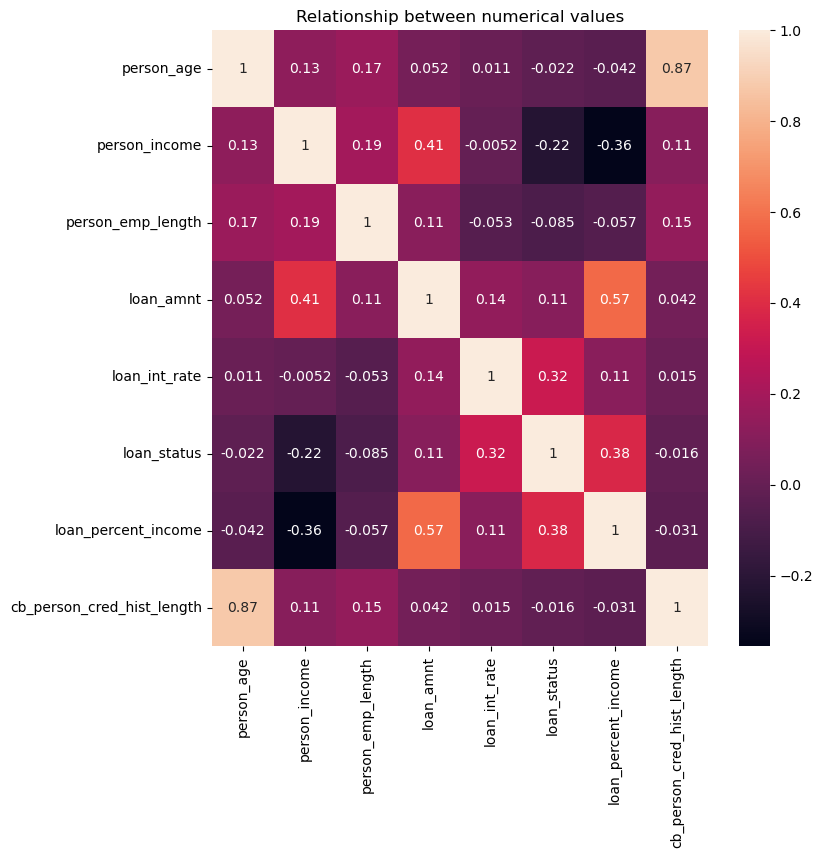

In [60]:
plt.figure(figsize = (8,8))

sns.heatmap(df[['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_status','loan_percent_income','cb_person_cred_hist_length']].corr(), annot = True)

plt.title('Relationship between numerical values')
plt.show()

In [61]:
df.to_csv('credit_risk_dataset_1.csv', index=False) 

In [62]:
df1 = pd.read_csv('credit_risk_dataset_1.csv')

In [63]:
df1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,60.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [64]:
X = df1.drop(['loan_status'], axis = 1)
y = df1[['loan_status']]

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2 , random_state = 0)

In [66]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25932, 11), (25932, 1), (6484, 11), (6484, 1))

In [67]:
num_col = ['person_age','person_income', 'person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
cat_col = ['person_home_ownership','loan_intent']
cat_lb_col = ['loan_grade', 'cb_person_default_on_file']

In [68]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
oe = OrdinalEncoder()
scaler = StandardScaler()
ohe = OneHotEncoder(sparse_output = False)

X_train_cat = ohe.fit_transform(X_train[cat_col])
X_test_cat = ohe.transform(X_test[cat_col])
X_train_cat_lb = oe.fit_transform(X_train[cat_lb_col])
X_test_cat_lb = oe.transform(X_test[cat_lb_col])

X_train_num = scaler.fit_transform(X_train[num_col])
X_test_num = scaler.transform(X_test[num_col])

X_train_df = pd.concat([pd.DataFrame(X_train_cat),pd.DataFrame(X_train_cat_lb), pd.DataFrame(X_train_num)], axis = 1)
X_test_df = pd.concat([pd.DataFrame(X_test_cat),pd.DataFrame(X_test_cat_lb), pd.DataFrame(X_test_num)], axis = 1)

In [69]:
X_train_df.shape, X_test_df.shape

((25932, 19), (6484, 19))

In [70]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_df, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_bal.value_counts())

Before: loan_status
0              20209
1               5723
Name: count, dtype: int64
After: loan_status
0              20209
1              20209
Name: count, dtype: int64


In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

knn = KNeighborsClassifier()
knn.fit(X_train_bal,y_train_bal)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [72]:
y_test_pred_knn = knn.predict(X_test_df)
print('Accuracy:',accuracy_score(y_test,y_test_pred_knn))
print('Confution matrix:\n',confusion_matrix(y_test,y_test_pred_knn))
print('Classification Report:\n',classification_report(y_test,y_test_pred_knn))

Accuracy: 0.8190931523750771
Confution matrix:
 [[4261  857]
 [ 316 1050]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.88      5118
           1       0.55      0.77      0.64      1366

    accuracy                           0.82      6484
   macro avg       0.74      0.80      0.76      6484
weighted avg       0.85      0.82      0.83      6484



In [73]:
LR = LogisticRegression()
LR.fit(X_train_bal,y_train_bal)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [74]:
y_test_pred_LR = LR.predict(X_test_df)
print('Accuracy:',accuracy_score(y_test,y_test_pred_LR))
print('Confution matrix:\n',confusion_matrix(y_test,y_test_pred_LR))
print('Classification Report:\n',classification_report(y_test,y_test_pred_LR))

Accuracy: 0.7930289944478717
Confution matrix:
 [[4085 1033]
 [ 309 1057]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      5118
           1       0.51      0.77      0.61      1366

    accuracy                           0.79      6484
   macro avg       0.72      0.79      0.74      6484
weighted avg       0.84      0.79      0.81      6484



In [75]:
dt = DecisionTreeClassifier()
dt.fit(X_train_bal,y_train_bal)

DecisionTreeClassifier()

In [76]:
y_test_pred_dt = dt.predict(X_test_df)
print('Accuracy:',accuracy_score(y_test,y_test_pred_dt))
print('Confution matrix:\n',confusion_matrix(y_test,y_test_pred_dt))
print('Classification Report:\n',classification_report(y_test,y_test_pred_dt))

Accuracy: 0.8792412091301666
Confution matrix:
 [[4627  491]
 [ 292 1074]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      5118
           1       0.69      0.79      0.73      1366

    accuracy                           0.88      6484
   macro avg       0.81      0.85      0.83      6484
weighted avg       0.89      0.88      0.88      6484



In [77]:
y_train_bal = y_train_bal.values.ravel()

In [78]:
RF = RandomForestClassifier()
RF.fit(X_train_bal,y_train_bal)

RandomForestClassifier()

In [79]:
y_test_pred_RF = RF.predict(X_test_df)
print('Accuracy:',accuracy_score(y_test,y_test_pred_RF))
print('Confution matrix:\n',confusion_matrix(y_test,y_test_pred_RF))
print('Classification Report:',classification_report(y_test,y_test_pred_RF))

Accuracy: 0.9322948797038865
Confution matrix:
 [[5040   78]
 [ 361 1005]]
Classification Report:               precision    recall  f1-score   support

           0       0.93      0.98      0.96      5118
           1       0.93      0.74      0.82      1366

    accuracy                           0.93      6484
   macro avg       0.93      0.86      0.89      6484
weighted avg       0.93      0.93      0.93      6484



In [80]:
preds = pd.DataFrame({'act' : y_test.values.ravel(), 'pred' : y_test_pred_RF})
preds.sample(5)

,act,pred
4916,0,0
528,0,0
2453,0,0
3218,0,0
6451,0,0


In [81]:
import pickle

pickle.dump(RF, open('RF_model.pkl', 'wb'))
